## Task 1.3: The Format Trade-off


In this task, we will:

- Take a high-quality PNG image
- Save it as a low-quality JPEG
- Reload both images
- Subtract them to see numerical differences

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


## Step 1: Load a High-Quality PNG Image

PNG uses lossless compression.
That means pixel values are preserved exactly.


In [2]:
img_png = cv2.imread("mountain.png")

if img_png is None:
    print("Image not found. Check file path.")
else:
    print("PNG image loaded successfully!")

print("Image Shape:", img_png.shape)


PNG image loaded successfully!
Image Shape: (864, 1152, 3)


## Step 2: Save as Low-Quality JPEG

JPEG uses lossy compression.

We reduce quality to 5 (very low) to exaggerate artifacts.


In [3]:
cv2.imwrite("compressed.jpg", img_png, [int(cv2.IMWRITE_JPEG_QUALITY), 5])

print("JPEG saved with quality=5")


JPEG saved with quality=5


## Step 3: Reload the Compressed Image


In [5]:
img_jpg = cv2.imread("compressed.jpg")

print("JPEG Shape:", img_jpg.shape)

JPEG Shape: (864, 1152, 3)


## Step 4: Compare Visually

They may look similar to us,
but the numerical values are different.


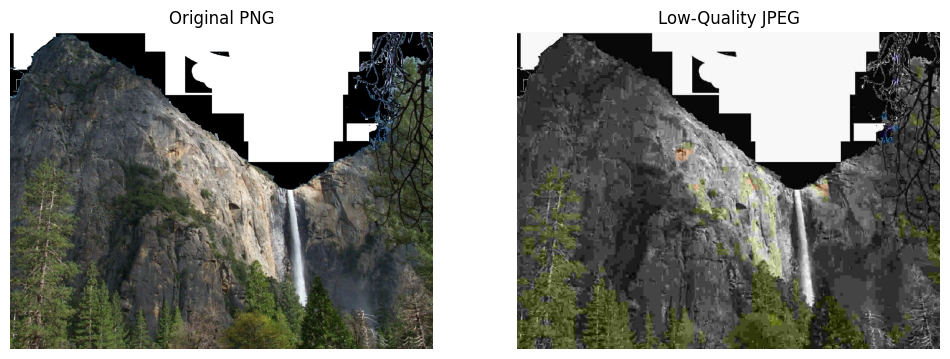

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_png, cv2.COLOR_BGR2RGB))
plt.title("Original PNG")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_jpg, cv2.COLOR_BGR2RGB))
plt.title("Low-Quality JPEG")
plt.axis("off")

plt.show()


## Step 5: Subtract the Images

Now we compute:

difference = PNG - JPEG

This shows how much compression changed the pixel values.


In [7]:
# Convert to int16 to avoid negative overflow
diff = img_png.astype(np.int16) - img_jpg.astype(np.int16)

print("Difference matrix sample:")
print(diff[100:110, 100:110])


Difference matrix sample:
[[[  9  11  -1]
  [ 16  18   6]
  [ 15  15   3]
  [  8   8  -4]
  [  4   4 -10]
  [  0   0 -14]
  [  2   1 -13]
  [ 12   6  -7]
  [ 15  10  -5]
  [ 11   6  -9]]

 [[  9  11  -1]
  [ 11  13   1]
  [ 13  13   1]
  [ 12  12   0]
  [  6   6  -8]
  [  4   4 -10]
  [  5   4 -10]
  [ 10   4  -9]
  [ 11   6  -9]
  [ 11   6  -9]]

 [[  1   5  -7]
  [  4   8  -4]
  [  7  11  -1]
  [ 13  13   1]
  [ 12  12  -2]
  [ 13  10  -4]
  [  8   5  -9]
  [  6   3 -11]
  [  9   4 -11]
  [ 13   8  -7]]

 [[ -5  -1 -13]
  [  1   5  -7]
  [  5   9  -3]
  [ 10  10  -2]
  [ 12  12  -2]
  [ 11   8  -6]
  [  4   1 -13]
  [ -1  -4 -18]
  [  4  -1 -16]
  [ 10   5 -10]]

 [[ -5  -4 -14]
  [ -2  -1 -11]
  [  2   2 -10]
  [ 12  12   0]
  [ 14  12   1]
  [ 10   8  -3]
  [  2  -1 -15]
  [ -4  -7 -21]
  [  8   5  -9]
  [  5   2 -12]]

 [[ -6  -5 -15]
  [  0   1  -9]
  [  2   2 -10]
  [  6   6  -6]
  [  8   6  -5]
  [  6   4  -7]
  [  1  -2 -16]
  [ -5  -8 -22]
  [  3   0 -14]
  [ -3  -6 -20]]

 [

The differences may be small.

We amplify them to make compression artifacts visible.


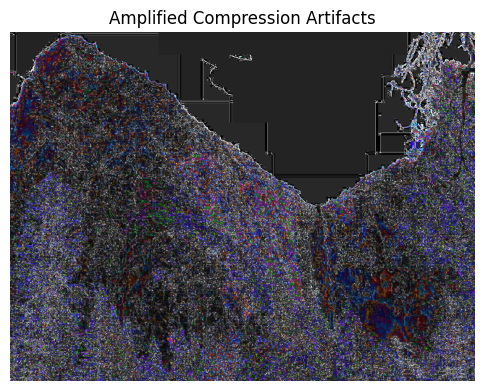

In [8]:
# Take absolute difference
abs_diff = np.abs(diff)

# Normalize for visualization
abs_diff = np.clip(abs_diff * 5, 0, 255).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(abs_diff, cv2.COLOR_BGR2RGB))
plt.title("Amplified Compression Artifacts")
plt.axis("off")
plt.show()
